# Transition Matrices with Aggregate Shocks (Krusell-Smith)

**From partial equilibrium to general equilibrium: TM meets the
aggregate feedback loop.**

This notebook demonstrates how the transition matrix method extends to
`AggShockMarkovConsumerType` — the Krusell-Smith (1998) model with
discrete Markov aggregate states.

## What's new compared to previous notebooks

| Previous (PE) | This notebook (GE) |
|---------------|-------------------|
| Prices $(R, W)$ are fixed parameters | Prices are *endogenous*: $R = R(K/L)$, $W = W(K/L)$ |
| $c(m)$ — 1D policy | $c(m, M)$ — 2D policy (depends on aggregate state $M$) |
| TM is time-invariant | TM varies with aggregate state $(M_t, z_t)$ |
| Single ergodic distribution | Distribution *is* the aggregate state |

## The Krusell-Smith Algorithm

1. **Guess** an aggregate law of motion: $\log A_{z} = a_z + b_z \log M$
2. **Solve** agents' problem given this law of motion → $c(m, M, z)$
3. **Simulate** the cross-sectional distribution forward → compute $A_t$
4. **Regress** $\log A_t$ on $\log M_t$ by Markov state → update $(a_z, b_z)$
5. **Iterate** until convergence

Step 3 is traditionally done with Monte Carlo.  The **TM approach** replaces
step 3 with deterministic distribution propagation — no sampling noise.

---

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse.linalg as sp_linalg

from HARK.ConsumptionSaving.ConsAggShockModel import (
    AggShockMarkovConsumerType,
    CobbDouglasMarkovEconomy,
)
from HARK.utilities import make_grid_exp_mult, jump_to_grid_1D

## 1. Solve the Krusell-Smith Economy

We use HARK's built-in MC-based KS algorithm to solve a 2-state
Markov Cobb-Douglas economy.

| State | PermGroFacAgg | Interpretation |
|-------|--------------|----------------|
| 0     | 0.98         | Recession      |
| 1     | 1.02         | Expansion      |

**Note:** This takes ~4 minutes due to the KS outer loop.

In [2]:
consumer = AggShockMarkovConsumerType(cycles=0)
econ = CobbDouglasMarkovEconomy(agents=[consumer], verbose=True)
econ.make_AggShkHist()
econ.give_agent_params()

t0 = time.time()
econ.solve()
elapsed = time.time() - t0
print(f"\nSolved in {elapsed:.0f} seconds")

intercept=[np.float64(-0.482916418198766), np.float64(-0.6286768645335784)], slope=[np.float64(1.1228671690799255), np.float64(1.1975925224299746)], r-sq=[np.float64(0.9983566435141913), np.float64(0.993999530186829)]


intercept=[np.float64(-0.31136898110022687), np.float64(-0.3166362223917491)], slope=[np.float64(1.0475161827021613), np.float64(1.0423783867707275)], r-sq=[np.float64(0.9998795814756987), np.float64(0.9997235487802072)]


intercept=[np.float64(-0.31772821019139563), np.float64(-0.3607467625500071)], slope=[np.float64(1.060032867137027), np.float64(1.0716972339492286)], r-sq=[np.float64(0.999947296464975), np.float64(0.9999330431328163)]


intercept=[np.float64(-0.33676608074401204), np.float64(-0.3838533140845089)], slope=[np.float64(1.066431108810626), np.float64(1.0798799983131717)], r-sq=[np.float64(0.9999431892865129), np.float64(0.9999287885763215)]


intercept=[np.float64(-0.3336881186128549), np.float64(-0.37898863566455954)], slope=[np.float64(1.0653641129930684), np.float64(1.0782096210498118)], r-sq=[np.float64(0.9999437881173592), np.float64(0.999928767185237)]


intercept=[np.float64(-0.3343143343570017), np.float64(-0.38001751642276044)], slope=[np.float64(1.0655782892719032), np.float64(1.078561138667419)], r-sq=[np.float64(0.9999437446206528), np.float64(0.9999288287833763)]


intercept=[np.float64(-0.3341768589228499), np.float64(-0.3797942743282447)], slope=[np.float64(1.06553141782149), np.float64(1.0784848717846809)], r-sq=[np.float64(0.9999437569948211), np.float64(0.9999288208033832)]


intercept=[np.float64(-0.334206890398842), np.float64(-0.379842837443582)], slope=[np.float64(1.0655416565055962), np.float64(1.078501460303492)], r-sq=[np.float64(0.9999437542500996), np.float64(0.9999288225499203)]

Solved in 252 seconds


## 2. Examine the Solution

After convergence, we have:

- **AFunc[z]**: Aggregate saving rule $\log A = a_z + b_z \log M$ for each Markov state
- **cFunc[z](m, M)**: Individual consumption function (2D!) for each state
- **Rfunc(K/L)**, **wFunc(K/L)**: Cobb-Douglas production functions
- **history**: Simulated trajectory of $M_t$, $A_t$, and $z_t$

In [3]:
M_hist = np.array(econ.history["MaggNow"])
A_hist = np.array(econ.history["AaggNow"])
Mrkv_hist = econ.MrkvNow_hist

print("=== Economy History ===")
print(f"M range: [{M_hist.min():.2f}, {M_hist.max():.2f}], mean: {M_hist.mean():.2f}")
print(f"A range: [{A_hist.min():.2f}, {A_hist.max():.2f}], mean: {A_hist.mean():.2f}")
print()
for j in [0, 1]:
    mask = Mrkv_hist == j
    label = "Recession" if j == 0 else "Expansion"
    print(
        f"State {j} ({label}): mean M = {M_hist[mask].mean():.2f}, "
        f"mean A = {A_hist[mask].mean():.2f}, count = {mask.sum()}/{len(Mrkv_hist)}"
    )

print(f"\nMrkvArray:\n{econ.MrkvArray}")
print(f"PermGroFacAgg: {econ.PermGroFacAgg}")

=== Economy History ===
M range: [8.98, 23.72], mean: 12.64
A range: [7.27, 20.82], mean: 10.63

State 0 (Recession): mean M = 15.97, mean A = 13.47, count = 381/1200
State 1 (Expansion): mean M = 11.09, mean A = 9.30, count = 819/1200

MrkvArray:
[[0.9  0.1 ]
 [0.04 0.96]]
PermGroFacAgg: [0.98, 1.02]


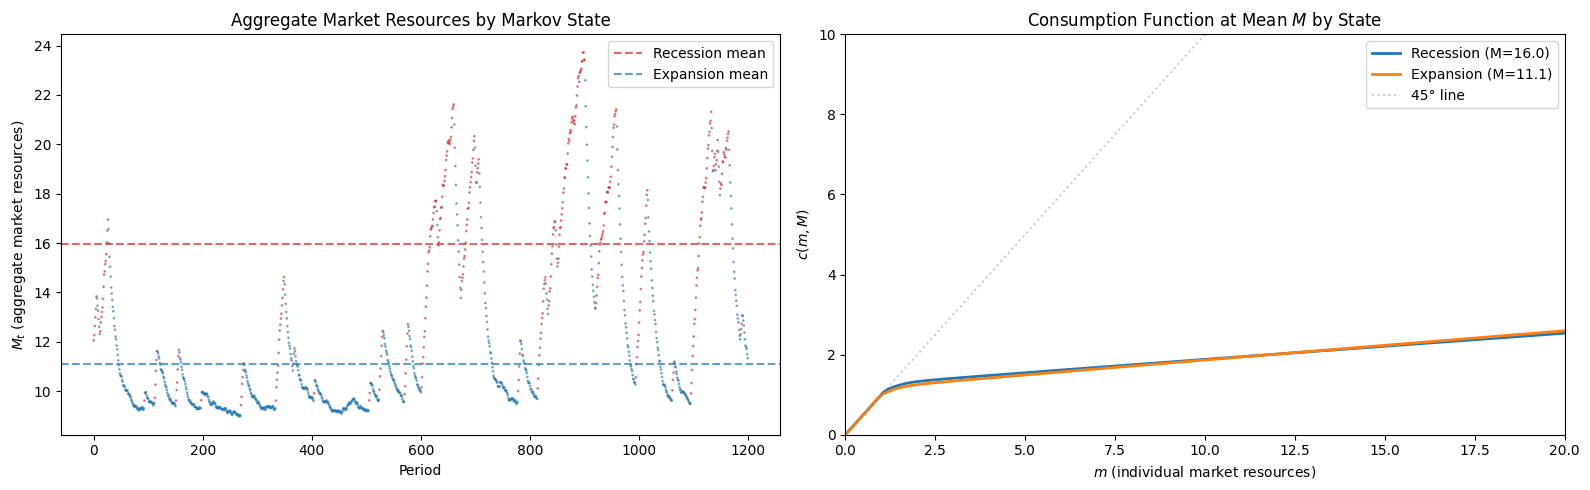

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# M history colored by Markov state
colors = np.where(Mrkv_hist == 0, "C3", "C0")
axes[0].scatter(range(len(M_hist)), M_hist, c=colors, s=1, alpha=0.5)
axes[0].set_xlabel("Period")
axes[0].set_ylabel("$M_t$ (aggregate market resources)")
axes[0].set_title("Aggregate Market Resources by Markov State")
axes[0].axhline(
    M_hist[Mrkv_hist == 0].mean(),
    color="C3",
    ls="--",
    alpha=0.7,
    label="Recession mean",
)
axes[0].axhline(
    M_hist[Mrkv_hist == 1].mean(),
    color="C0",
    ls="--",
    alpha=0.7,
    label="Expansion mean",
)
axes[0].legend()

# 2D consumption function slices
m_plot = np.linspace(0.01, 30, 200)
M_vals = [M_hist[Mrkv_hist == 0].mean(), M_hist[Mrkv_hist == 1].mean()]
for j in range(2):
    label = "Recession" if j == 0 else "Expansion"
    M_j = M_vals[j]
    c_vals = consumer.solution[0].cFunc[j](m_plot, M_j * np.ones_like(m_plot))
    axes[1].plot(m_plot, c_vals, label=f"{label} (M={M_j:.1f})", linewidth=2)
axes[1].plot(m_plot, m_plot, ":", color="gray", alpha=0.4, label="45° line")
axes[1].set_xlabel("$m$ (individual market resources)")
axes[1].set_ylabel("$c(m, M)$")
axes[1].set_title("Consumption Function at Mean $M$ by State")
axes[1].set_xlim([0, 20])
axes[1].set_ylim([0, 10])
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Build Transition Matrices at the Steady State

At a fixed aggregate state $(M, z)$, the individual transition is:

$$m' = R \cdot \frac{a}{\psi} + W \cdot \theta$$

where:
- $c = c_z(m, M)$ → $a = m - c$
- $K = A_z(M)$ → capital from aggregate saving rule
- $R = R_{\text{func}}(K)$, $W = W_{\text{func}}(K)$ → Cobb-Douglas prices
- $(\psi, \theta)$ ~ idiosyncratic shock distribution for state $z$

We build one TM per Markov state, evaluated at that state's
mean $M$ from the simulation history.

In [5]:
mMin, mMax, mCount, mFac = 0.001, 50, 200, 3
dist_mGrid = make_grid_exp_mult(ming=mMin, maxg=mMax, ng=mCount, timestonest=mFac)
M_grid = len(dist_mGrid)

print(f"m-grid: {M_grid} points from {dist_mGrid[0]:.4f} to {dist_mGrid[-1]:.1f}")

m-grid: 200 points from 0.0010 to 50.0


In [6]:
t0 = time.time()

J = 2
LivPrb = consumer.LivPrb[0]

TranMatrices = []
cPols = []
aPols = []
R_vals = []
W_vals = []

for j in range(J):
    M_j = M_hist[Mrkv_hist == j].mean()
    # Evaluate 2D consumption function at fixed M → 1D policy
    c_j = consumer.solution[0].cFunc[j](dist_mGrid, M_j * np.ones(M_grid))
    a_j = np.maximum(dist_mGrid - c_j, 0.0)
    cPols.append(c_j)
    aPols.append(a_j)

    # Cobb-Douglas prices: R and W from capital-to-labor ratio
    # At steady state: A = aggregate assets from history
    A_j = A_hist[Mrkv_hist == j].mean()
    K_j = A_j
    R_j = econ.Rfunc(K_j)
    W_j = econ.wFunc(K_j)
    R_vals.append(R_j)
    W_vals.append(W_j)

    # Income shocks for this Markov state
    dstn_j = consumer.IncShkDstn[0][j]
    perm_shks = dstn_j.atoms[0]
    tran_shks = dstn_j.atoms[1]
    shk_prbs = dstn_j.pmv

    # Newborn distribution: a=0, receive transitory labor income W*θ
    newborn_m = W_j * tran_shks
    newborn_1d = jump_to_grid_1D(newborn_m, shk_prbs, dist_mGrid)

    # Build TM
    TM_j = np.zeros((M_grid, M_grid))
    for i in range(M_grid):
        bNext = R_j * a_j[i]
        mNext = bNext / perm_shks + W_j * tran_shks
        lottery = jump_to_grid_1D(mNext, shk_prbs, dist_mGrid)
        TM_j[:, i] = LivPrb * lottery + (1.0 - LivPrb) * newborn_1d

    TranMatrices.append(TM_j)

    col_sums = TM_j.sum(axis=0)
    label = "Recession" if j == 0 else "Expansion"
    print(f"State {j} ({label}): M_ss={M_j:.2f}, K={K_j:.2f}, R={R_j:.4f}, W={W_j:.4f}")
    print(f"  Col sums: min={col_sums.min():.8f}, max={col_sums.max():.8f}")

elapsed = time.time() - t0
print(f"\nTransition matrices built in {elapsed:.1f} seconds")

State 0 (Recession): M_ss=15.97, K=13.47, R=1.0431, W=1.6323
  Col sums: min=1.00000000, max=1.00000000
State 1 (Expansion): M_ss=11.09, K=9.30, R=1.0614, W=1.4285
  Col sums: min=1.00000000, max=1.00000000

Transition matrices built in 0.9 seconds


## 4. Ergodic Distributions at Steady State

For each Markov state, find the ergodic distribution of the TM.
Compare with the MC cross-section from the last period of the simulation.

In [7]:
erg_dists = []
for j in range(J):
    eigenvalues, eigenvectors = sp_linalg.eigs(
        TranMatrices[j], k=1, which="LM", v0=np.ones(M_grid)
    )
    erg_j = eigenvectors[:, 0].real
    erg_j = erg_j / erg_j.sum()
    erg_dists.append(erg_j)

    TM_A = np.dot(aPols[j], erg_j)
    TM_C = np.dot(cPols[j], erg_j)
    label = "Recession" if j == 0 else "Expansion"
    print(f"State {j} ({label}):")
    print(f"  TM mean assets (norm) = {TM_A:.4f}")
    print(f"  TM mean consumption   = {TM_C:.4f}")

State 0 (Recession):
  TM mean assets (norm) = 8.4600
  TM mean consumption   = 1.8989
State 1 (Expansion):
  TM mean assets (norm) = 7.2122
  TM mean consumption   = 1.7831


In [8]:
# MC comparison: get cross-section from the last simulation
mc_mNrm = consumer.state_now["mNrm"]
mc_aNrm = consumer.state_now["aNrm"]
mc_cNrm = mc_mNrm - mc_aNrm
mc_Mrkv_now = int(Mrkv_hist[-1])

label = "Recession" if mc_Mrkv_now == 0 else "Expansion"
print(f"Last period Markov state: {mc_Mrkv_now} ({label})")
print(f"MC mean m = {mc_mNrm.mean():.4f}")
print(f"MC mean a = {mc_aNrm.mean():.4f}")
print(f"MC mean c = {mc_cNrm.mean():.4f}")

Last period Markov state: 1 (Expansion)
MC mean m = 18.9503
MC mean a = 16.4317
MC mean c = 2.5185


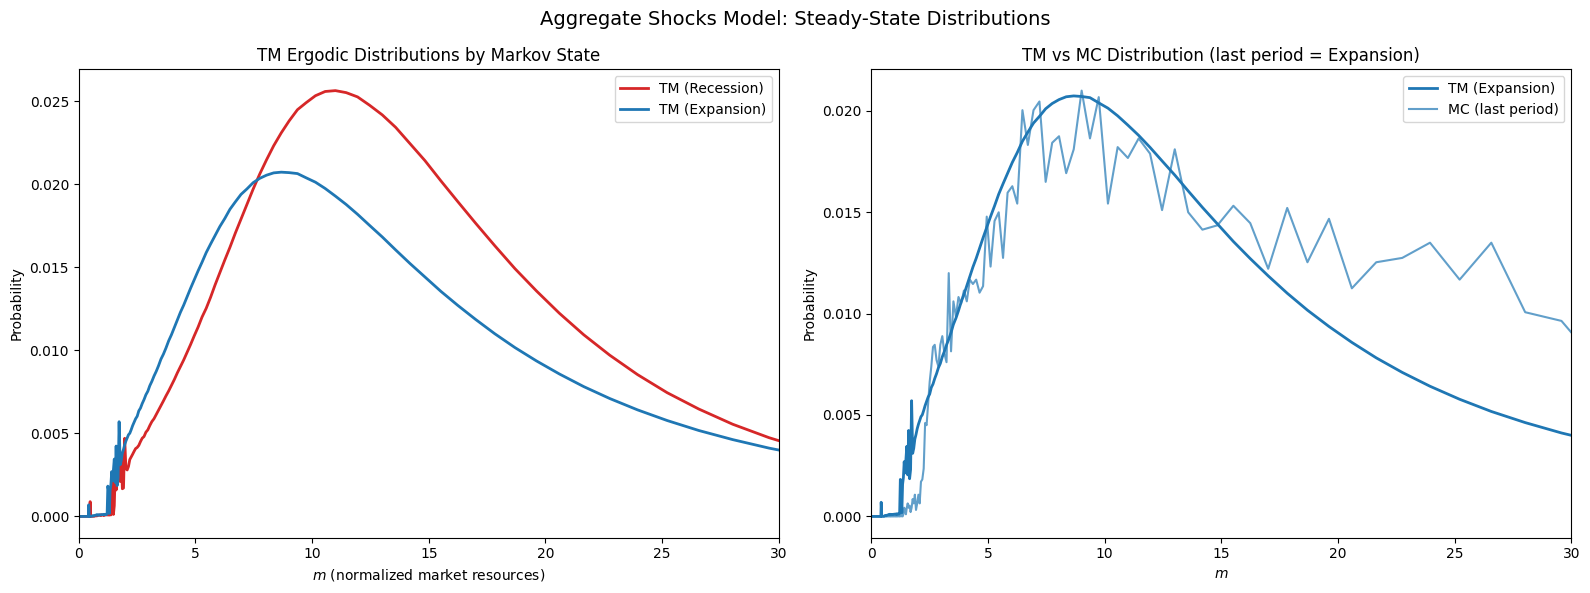

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for j in range(J):
    label = "Recession" if j == 0 else "Expansion"
    color = "C3" if j == 0 else "C0"
    axes[0].plot(
        dist_mGrid, erg_dists[j], label=f"TM ({label})", linewidth=2, color=color
    )
axes[0].set_xlabel("$m$ (normalized market resources)")
axes[0].set_ylabel("Probability")
axes[0].set_title("TM Ergodic Distributions by Markov State")
axes[0].set_xlim([0, 30])
axes[0].legend()

# Overlay MC histogram
j = mc_Mrkv_now
label = "Recession" if j == 0 else "Expansion"
color = "C3" if j == 0 else "C0"
axes[1].plot(dist_mGrid, erg_dists[j], label=f"TM ({label})", linewidth=2, color=color)
h, _ = np.histogram(mc_mNrm, bins=dist_mGrid)
h = h / h.sum()
axes[1].plot(dist_mGrid[:-1], h, label="MC (last period)", alpha=0.7, linewidth=1.5)
axes[1].set_xlabel("$m$")
axes[1].set_ylabel("Probability")
axes[1].set_title(f"TM vs MC Distribution (last period = {label})")
axes[1].set_xlim([0, 30])
axes[1].legend()

plt.suptitle("Aggregate Shocks Model: Steady-State Distributions", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Forward Propagation Through Aggregate Shocks

The real power of TM in the KS context: propagate the distribution
forward through the **same sequence of Markov states** as the MC simulation,
and compare the implied aggregate trajectories.

For each period $t$:
1. Use the TM for the current Markov state $z_t$
2. Propagate $\pi_t \to \pi_{t+1}$
3. Compute $A_t^{TM} = \sum_m a(m, M_t) \cdot \pi_t(m)$

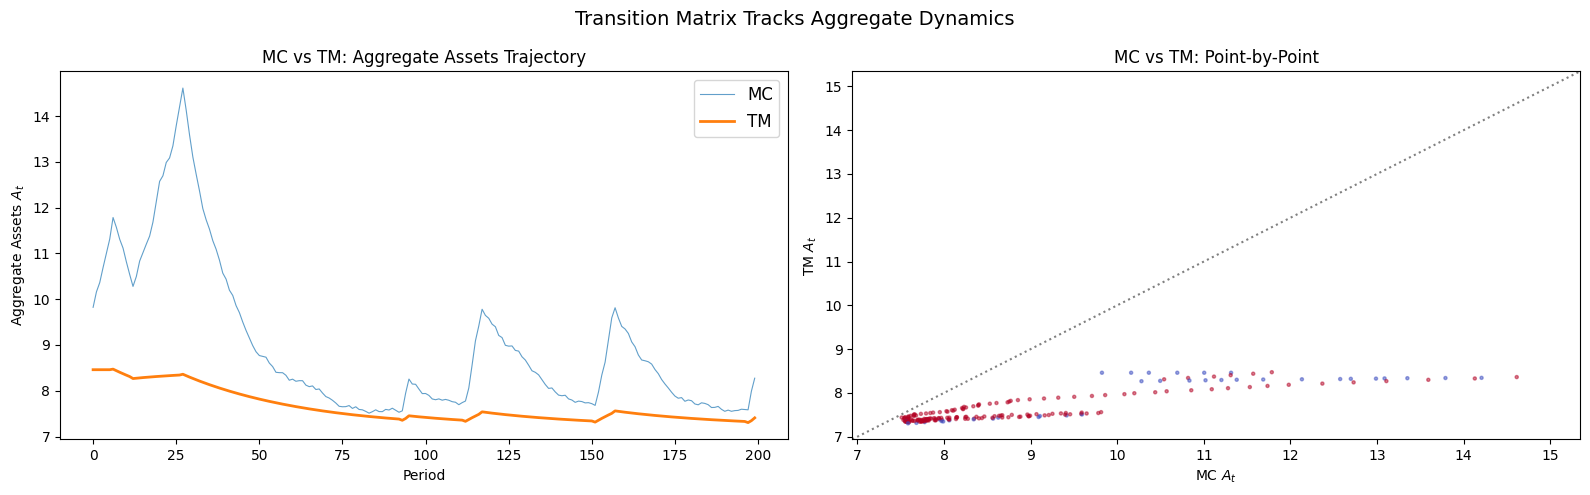

Correlation(MC, TM): 0.8848
MC mean A: 8.9645
TM mean A: 7.6506


In [10]:
T_forward = min(200, len(Mrkv_hist))

# Start from the ergodic distribution of the initial Markov state
j_init = int(Mrkv_hist[0])
dstn = erg_dists[j_init].copy()

tm_A_ts = []
for t in range(T_forward):
    j_t = int(Mrkv_hist[t])
    # Aggregate assets from current distribution + state
    A_t = np.dot(aPols[j_t], dstn)
    tm_A_ts.append(A_t)
    # Propagate distribution using current state's TM
    dstn = TranMatrices[j_t] @ dstn

mc_A_ts = A_hist[:T_forward]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(mc_A_ts, label="MC", alpha=0.7, linewidth=0.8)
axes[0].plot(tm_A_ts, label="TM", linewidth=2)
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Aggregate Assets $A_t$")
axes[0].set_title("MC vs TM: Aggregate Assets Trajectory")
axes[0].legend(fontsize=12)

# Scatter: TM vs MC
axes[1].scatter(
    mc_A_ts, tm_A_ts, s=5, alpha=0.5, c=Mrkv_hist[:T_forward], cmap="coolwarm"
)
lims = [min(min(mc_A_ts), min(tm_A_ts)) * 0.95, max(max(mc_A_ts), max(tm_A_ts)) * 1.05]
axes[1].plot(lims, lims, ":", color="gray")
axes[1].set_xlabel("MC $A_t$")
axes[1].set_ylabel("TM $A_t$")
axes[1].set_title("MC vs TM: Point-by-Point")
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)

plt.suptitle("Transition Matrix Tracks Aggregate Dynamics", fontsize=14)
plt.tight_layout()
plt.show()

corr = np.corrcoef(mc_A_ts, tm_A_ts)[0, 1]
print(f"Correlation(MC, TM): {corr:.4f}")
print(f"MC mean A: {np.mean(mc_A_ts):.4f}")
print(f"TM mean A: {np.mean(tm_A_ts):.4f}")

## 6. Summary

This notebook demonstrates the transition matrix method in the context of
the Krusell-Smith (1998) model with Markov aggregate states.

### Key differences from partial equilibrium TM

1. **2D policy function:** $c(m, M, z)$ depends on aggregate state $M$,
   not just individual state $m$.  At a fixed $M$, it reduces to a 1D policy.

2. **Endogenous prices:** $R = R(K/L)$ and $W = W(K/L)$ where $K$ comes from
   the aggregate saving rule — agents' savings determine the interest rate.

3. **TM varies with aggregate state:** Each period's TM depends on the
   current $(M_t, z_t)$ because policies and prices change.

4. **The distribution IS the state:** In GE, the full cross-sectional
   distribution matters for aggregates, not just its mean.

### What TM buys you in Krusell-Smith

- **Zero sampling noise** in distribution tracking → cleaner aggregate trajectories
- **Exact derivatives** (Jacobians) for sequence-space methods
- **Faster convergence** of the KS outer loop (less noise in regression)

### Limitations of this prototype

This notebook uses the TM at the **steady-state** M for each Markov state,
which is a simplification.  A full TM-in-KS implementation would:

1. Build TMs at **arbitrary M values** (not just the mean)
2. Recompute prices and policies at each M
3. Replace the MC simulation step entirely
4. Enable sequence-space Jacobian computation (as in Du's
   `Transition_Matrix_Example.ipynb`)

### Notebook progression

| # | Notebook | New concept |
|---|----------|-------------|
| 1 | `markov-tm-prototype` | Hand-built TM for 2-state Markov |
| 2 | `serial-unemployment-tm` | Scaling to 4 states |
| 3 | `serial-growth-tm-2d` | 2D grid for PermGroFac ≠ 1 |
| 4 | `serial-growth-tm-harmenberg` | Harmenberg neutral measure |
| 5 | `tm-consolidation` | Validates hand-built = HARK built-in |
| 6 | **`agg-shock-markov-tm`** | **GE feedback, Krusell-Smith** |